---
title: Water level measurement timeseries Lago di Santa Giustina
subtitle: Timeseries of water level measurements at Lago di Santa Giustina, Italy
authors:
  - name: Juraj Zvolenský
    orcid: 0009-0000-9185-7955
    github: jzvolensky
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2025-10-02
thumbnail: https://raw.githubusercontent.com/EOPF-Sample-Service/eopf-sample-notebooks/refs/heads/main/notebooks/static/ESA_logo_2020_Deep.png
keywords: ["earth observation", "remote sensing", "water level", "timeseries", "lake", "Italy"]
tags: ["notebook", "data", "timeseries", "water level", "lake"]
releaseDate:  2025-10-02
datePublished:  2025-10-02
dateModified:  2025-10-02
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/ESA_EOPF_logo_2025_COLOR_ESA_blue_reduced.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

## Table of contents

- [Introduction](#Introduction)
- [Setup](#Setup)
- [Read EOPF-Zarr](#Read-EOPF-Zarr)

(Introduction_water)=
## Introduction

This notebook demonstrates how to read and visualize water level measurements at Lago di Santa Giustina, Italy, using data stored in EOPF-Zarr format. 

The water level timeseries data is derived from the Sentinel-2 imagery.

The workflow demonstrates how to:
- Access the EOPF Zarr data
- Filter the data so that only almost cloud-free observations are retained
- Calculate NDWI (Normalized Difference Water Index)
- Extract water level measurements using skimage's otsu_threshold method
- Visualize the water level timeseries

## The lake

Lago di Santa Giustina is an artificial lake located in the Trentino region of northern Italy. It was created in the 1950s by damming the Noce River for hydroelectric power generation. The lake is situated at an elevation of approximately 500 meters above sea level and has a surface area of about 3.5 square kilometers.

![Lago di Santa Giustina](../static/lago-santa-gustina.png)

Image source: By Mosco - Own work, CC BY-SA 3.0, https://commons.wikimedia.org/w/index.php?curid=5144281

:::{hint} Overview

**Questions**
- How can we detect water bodies using Sentinel-2 imagery?
- How can we extract water level measurements from EOPF-Zarr data?
- How can we visualize the water level timeseries?

**Objectives**
- Detect the water body
- Extract water level measurements
- Visualize the water level timeseries

:::

(Setup_water)=
## Setup
Start importing the necessary libraries

In [1]:
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pystac_client
from pystac_client import CollectionSearch
from rasterio.features import geometry_mask

from skimage.filters import threshold_otsu

from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
from pyproj import Transformer
from concurrent.futures import as_completed

from distributed import LocalCluster

In [2]:
cluster = LocalCluster(processes=False, n_workers=4, threads_per_worker=1)
client = cluster.get_client()
cluster

LocalCluster(65838fdc, 'inproc://10.8.244.70/2645256/1', workers=4, threads=4, memory=31.34 GiB)

/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/skimage/exposure/exposure.py:307: RuntimeWarning: overflow encountered in add
  bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/skimage/filters/thresholding.py:396: RuntimeWarning: overflow encountered in multiply
  mean1 = np.cumsum(counts * bin_centers) / weight1
/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/skimage/filters/thresholding.py:396: RuntimeWarning: invalid value encountered in multiply
  mean1 = np.cumsum(counts * bin

In [ ]:
# TODO: Use this once the data has been reprocessed

# from xcube.core.store import new_data_store
# from xcube_eopf.utils import reproject_bbox
# store = new_data_store("eopf-zarr")

# bbox=[11.003288060439315, 46.34055268553584, 11.10369555555596, 46.40183319621778] # or bbox
# crs_utm = "EPSG:32632"
# bbox_utm = reproject_bbox(bbox, "EPSG:4326", crs_utm)
# ds = store.open_data(
#     data_id="sentinel-2-l2a",
#     bbox=bbox_utm,
#     time_range=["2022-12-31", "2024-01-01"],
#     spatial_res=10,
#     crs=crs_utm,
#     variables=[
#         "b04",
#         "b03",
#         "b02",
#         "b08",
#     ],
# )
# ds

In [3]:
search = CollectionSearch(
    url="https://stac.core.eopf.eodc.eu/collections",
)
for collection_dict in search.collections_as_dicts():
    print(collection_dict["id"])

sentinel-2-l2a
sentinel-3-olci-l2-lfr
sentinel-3-slstr-l2-lst
sentinel-1-l2-ocn
sentinel-1-l1-grd
sentinel-2-l1c
sentinel-1-l1-slc
sentinel-3-slstr-l1-rbt
sentinel-3-olci-l1-efr
sentinel-3-olci-l1-err
sentinel-3-olci-l2-lrr


In [4]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=[
            11.003288060439315,
            46.34055268553584,
            11.10369555555596,
            46.40183319621778,
        ],
        datetime=["2020-12-31", "2024-01-01"],
    ).items()
)
print(f"items found: {len(items)}")

items found: 434


In [ ]:
def reproject_bbox(bbox, src_crs="EPSG:4326", dst_crs="EPSG:32632"):
    transformer = Transformer.from_crs(src_crs, dst_crs, always_xy=True)
    xmin, ymin = transformer.transform(bbox[0], bbox[1])
    xmax, ymax = transformer.transform(bbox[2], bbox[3])
    return [xmin, ymin, xmax, ymax]


bbox = [11.003288060439315, 46.34055268553584, 11.10369555555596, 46.40183319621778]


def load_tile(item, bbox_ll):
    href = item.assets["product"].href
    ds = xr.open_datatree(href, engine="zarr", chunks={}, mask_and_scale=True)

    dst_crs = item.properties.get("proj:code")
    if dst_crs is None:
        raise ValueError(f"No proj:code in item {item.id}")

    utm_bbox = reproject_bbox(bbox_ll, dst_crs=dst_crs)

    ds_ref = (
        ds["measurements"]["reflectance"]["r20m"]
        .ds.sel(x=slice(utm_bbox[0], utm_bbox[2]), y=slice(utm_bbox[3], utm_bbox[1]))
        .expand_dims(time=[item.datetime])
    )

    ds_scl = (
        ds["conditions"]["mask"]["l2a_classification"]["r20m"]
        .ds.sel(x=slice(utm_bbox[0], utm_bbox[2]), y=slice(utm_bbox[3], utm_bbox[1]))
        .expand_dims(time=[item.datetime])
    )

    return ds_ref, ds_scl


results = []
with ThreadPoolExecutor(max_workers=8) as ex:
    futures = [ex.submit(load_tile, item, bbox) for item in items]
    for f in tqdm(as_completed(futures), total=len(futures), desc="Loading tiles"):
        results.append(f.result())

r20m_datasets, scl_datasets = zip(*results)

r20m = xr.concat(r20m_datasets, dim="time")
scl_cube = xr.concat(scl_datasets, dim="time")
datacube = xr.merge([r20m, scl_cube]).sortby("time")

datacube

Loading tiles: 100%|██████████| 434/434 [02:26<00:00,  2.97it/s]


<xarray.Dataset> Size: 5GB
Dimensions:  (time: 434, y: 350, x: 377)
Coordinates:
  * time     (time) object 3kB 1609496609024000000 ... 1703844871024000000
  * x        (x) float32 2kB 6.542e+05 6.542e+05 ... 6.617e+05 6.617e+05
  * y        (y) float32 1kB 5.141e+06 5.141e+06 ... 5.134e+06 5.134e+06
Data variables:
    b01      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b02      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b03      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b04      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b05      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b06      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b07      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b11      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b12      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b8a      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    scl      (time, y, x) float64 458MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>

In [6]:
# Get CRS from STAC item
crs = items[0].properties.get("proj:code")
print("CRS:", crs)
# assign to datacube
datacube = datacube.rio.write_crs(crs, inplace=True)

CRS: EPSG:32632


In [8]:
# Open and align lake geojson
lake_gdf = gpd.read_file("lago_santa_giustina.geojson")
lake_gdf = lake_gdf.to_crs(crs)

## Visualize datacube sample

In this section we visualize an RGB composite for a random date and use the lake polygon as an outline to see if it is aligned correctly.


/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 59.27 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


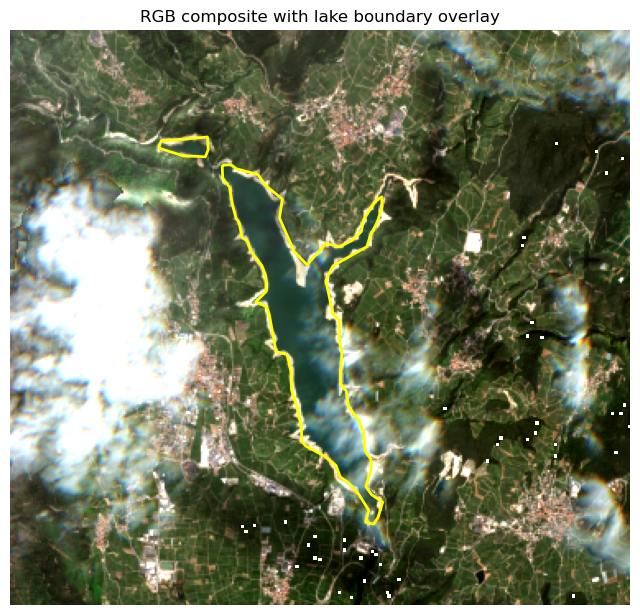

In [ ]:
datacube_sample = datacube.isel(time=50)

rgb = datacube_sample[["b04", "b03", "b02"]].to_dataarray(dim="band")

rgb = rgb.assign_coords(band=["red", "green", "blue"])

vmin, vmax = 0, 0.25
rgb_scaled = (rgb - vmin) / (vmax - vmin)
rgb_scaled = rgb_scaled.clip(0, 1)

rgb_img = rgb_scaled.transpose("y", "x", "band").values

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(
    rgb_img,
    extent=[
        float(rgb.x.min()),
        float(rgb.x.max()),
        float(rgb.y.min()),
        float(rgb.y.max()),
    ],
)

lake_gdf.boundary.plot(ax=ax, edgecolor="yellow", linewidth=2)
ax.set_title("RGB composite with lake boundary overlay")
ax.axis("off")
plt.show()

## Cloud masking

In this section we apply the `scl` band to mask out the clouds. We visualize the same RGB composite as before, but with the mask applied.

/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 60.24 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


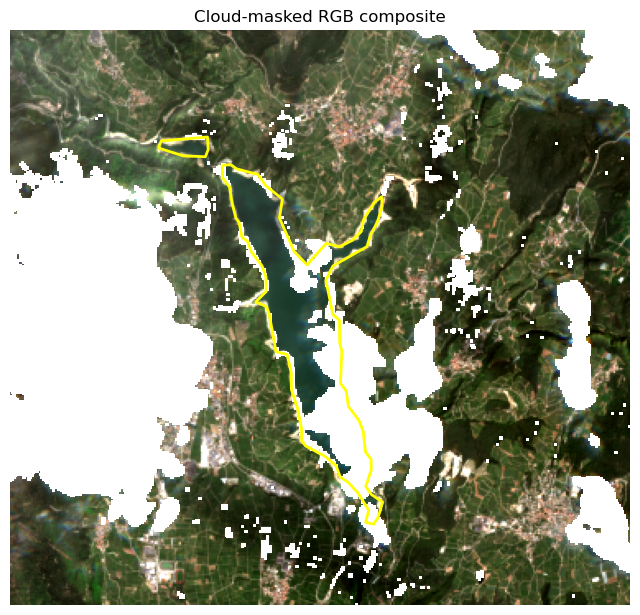

In [10]:
valid_classes = [2, 4, 5, 6]

mask = datacube["scl"].isin(valid_classes)

datacube_masked = datacube.where(mask)

datacube_sample = datacube_masked.isel(time=50)

rgb = datacube_sample[["b04", "b03", "b02"]].to_dataarray(dim="band")

rgb = rgb.assign_coords(band=["red", "green", "blue"])

vmin, vmax = 0, 0.25
rgb_scaled = (rgb - vmin) / (vmax - vmin)
rgb_scaled = rgb_scaled.clip(0, 1)  # keep in [0, 1]
rgb_img = rgb_scaled.transpose("y", "x", "band").values

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(
    rgb_img,
    extent=[
        float(rgb.x.min()),
        float(rgb.x.max()),
        float(rgb.y.min()),
        float(rgb.y.max()),
    ],
)
lake_gdf.boundary.plot(ax=ax, edgecolor="yellow", linewidth=2)
ax.set_title("Cloud-masked RGB composite")
ax.axis("off")
plt.show()

In [11]:
valid_classes = [4, 5, 6]
lake_mask = datacube["scl"].rio.clip(lake_gdf.geometry, lake_gdf.crs)

clear_mask = lake_mask.isin(valid_classes)

clear_fraction = clear_mask.mean(dim=("y", "x")).compute()  # values 0–1

threshold = 0.05
good_times = clear_fraction.time[clear_fraction >= threshold]

datacube_clear = datacube.where(clear_fraction >= threshold, drop=True)

datacube_clear

/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 57.62 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.Dataset> Size: 3GB
Dimensions:      (time: 256, y: 350, x: 377)
Coordinates:
  * time         (time) object 2kB 1610100799024000000 ... 1702980871024000000
  * x            (x) float32 2kB 6.542e+05 6.542e+05 ... 6.617e+05 6.617e+05
  * y            (y) float32 1kB 5.141e+06 5.141e+06 ... 5.134e+06 5.134e+06
    spatial_ref  int64 8B 0
Data variables:
    b01          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b02          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b03          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b04          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b05          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b06          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b07          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b11          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b12          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    b8a          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>
    scl          (time, y, x) float64 270MB dask.array<chunksize=(1, 350, 37), meta=np.ndarray>

## NDWI

Water detection is performed using the Normalized Difference Water Index (NDWI), which utilizes the green and near-infrared (NIR) bands of the Sentinel-2 imagery. The NDWI is calculated as follows:

NDWI = (Green - NIR) / (Green + NIR)


In [12]:
ndwi = (datacube_clear["b03"] - datacube_clear["b8a"]) / (
    datacube_clear["b03"] + datacube_clear["b8a"]
)

In [ ]:
def otsu_mask(arr):
    arr = np.clip(np.nan_to_num(arr, nan=0.0), -1, 1)

    valid = arr > -0.2
    if np.count_nonzero(valid) < 10:
        return np.zeros_like(arr, dtype=bool)
    try:
        thr = threshold_otsu(arr[valid])
    except Exception:
        thr = 0.0
    thr -= 0.05

    return arr > thr


ndwi = ndwi.chunk({"x": -1, "y": -1})
water_masks = xr.apply_ufunc(
    otsu_mask,
    ndwi,
    input_core_dims=[["y", "x"]],
    output_core_dims=[["y", "x"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[bool],
)

water_masks.compute()

water_masks

/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 58.54 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.DataArray (time: 256, y: 350, x: 377)> Size: 34MB
dask.array<transpose, shape=(256, 350, 377), dtype=bool, chunksize=(1, 350, 377), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) object 2kB 1610100799024000000 ... 1702980871024000000
  * x            (x) float32 2kB 6.542e+05 6.542e+05 ... 6.617e+05 6.617e+05
  * y            (y) float32 1kB 5.141e+06 5.141e+06 ... 5.134e+06 5.134e+06
    spatial_ref  int64 8B 0

/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 59.48 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 58.54 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Water mask shape: (350, 377)
Water pixels: 4899
Unique values: [False  True]


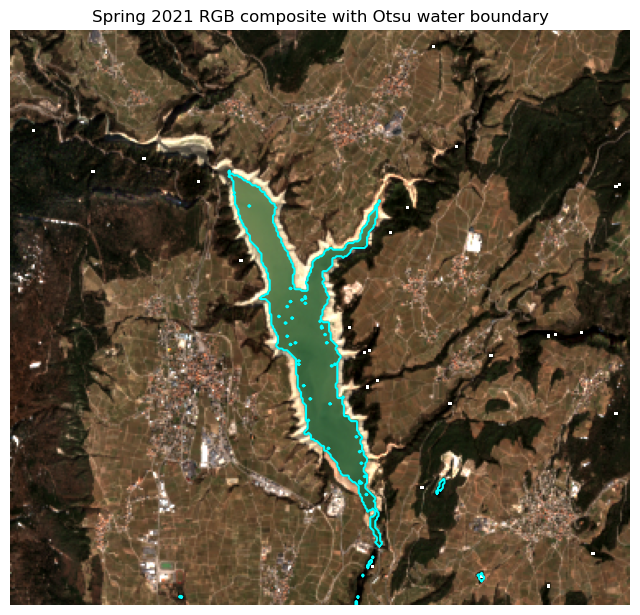

In [ ]:
import pandas as pd
from skimage import measure

datacube_sample = datacube_clear.sel(time="2021-04", method="nearest")

rgb = datacube_sample[["b04", "b03", "b02"]].to_dataarray(dim="band")

rgb = rgb.assign_coords(band=["red", "green", "blue"])

vmin, vmax = 0, 0.25
rgb_scaled = (rgb - vmin) / (vmax - vmin)
rgb_scaled = rgb_scaled.clip(0, 1)  # keep in [0, 1]
rgb_img = rgb_scaled.transpose("y", "x", "band").values

water_masks = water_masks.assign_coords(
    time=pd.to_datetime(water_masks.time.values).tz_localize(None)
)
water_mask = water_masks.sel(time=datacube_sample.time, method="nearest").values

contours = measure.find_contours(water_mask, 0.5)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(
    rgb_img,
    extent=[
        float(rgb.x.min()),
        float(rgb.x.max()),
        float(rgb.y.min()),
        float(rgb.y.max()),
    ],
)

x_vals = np.linspace(float(rgb.x.min()), float(rgb.x.max()), water_mask.shape[1])
y_vals = np.linspace(
    float(rgb.y.max()), float(rgb.y.min()), water_mask.shape[0]
)  # y is often inverted

for contour in contours:
    ax.plot(
        np.interp(contour[:, 1], np.arange(len(x_vals)), x_vals),
        np.interp(contour[:, 0], np.arange(len(y_vals)), y_vals),
        color="cyan",
        linewidth=1.5,
    )

ax.set_title("Spring 2021 RGB composite with Otsu water boundary")
ax.axis("off")
plt.show()

In [41]:
lake_masked = []

for t in range(len(datacube_clear.time)):
    wm = xr.DataArray(
        water_masks[t],
        dims=("y", "x"),
        coords={"y": datacube_clear.y, "x": datacube_clear.x},
        name="water_mask",
    ).rio.write_crs(datacube_clear.rio.crs)

    mask = geometry_mask(
        [lake_gdf.geometry.unary_union],
        transform=wm.rio.transform(),
        invert=True,
        out_shape=wm.shape,
    )
    wm_clipped = wm.where(mask)
    lake_masked.append(wm_clipped)

water_masks_clipped = xr.concat(lake_masked, dim="time")
print((water_masks_clipped == 1).sum(dim=("y", "x")).isel(time=0).values)

/tmp/ipykernel_2645256/3551280887.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  [lake_gdf.geometry.unary_union],
/tmp/ipykernel_2645256/3551280887.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  [lake_gdf.geometry.unary_union],
/tmp/ipykernel_2645256/3551280887.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  [lake_gdf.geometry.unary_union],
/tmp/ipykernel_2645256/3551280887.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  [lake_gdf.geometry.unary_union],
/tmp/ipykernel_2645256/3551280887.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  [lake_gdf.geometry.unary_union],
/tmp/ipykernel_2645256/3551280887.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'un

6349


In [42]:
water_fraction = water_masks_clipped.sum(dim=("y", "x")) / (
    water_masks_clipped.notnull().sum(dim=("y", "x"))
)

In [43]:
import pandas as pd

df_water = pd.DataFrame(
    {"time": water_fraction.time.values, "water_fraction": water_fraction.values}
)
df_water.set_index("time", inplace=True)
print(df_water.head())

/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 59.05 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


      water_fraction
time                
0           0.908298
1           0.877253
2           0.861373
3           0.859657
4           0.573534


In [44]:
pixel_area_m2 = 20 * 20

water_pixel_count = (water_masks_clipped == 1).sum(dim=("y", "x"))
water_area_m2 = water_pixel_count * pixel_area_m2

water_area_m2 = water_area_m2.assign_coords(time=water_masks_clipped.time)

dates = pd.to_datetime(water_masks.time.values)

water_area_ts = pd.Series(water_area_m2.values, index=dates)

/home/jzvolensky/miniconda3/envs/eopf-zarr/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 59.04 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


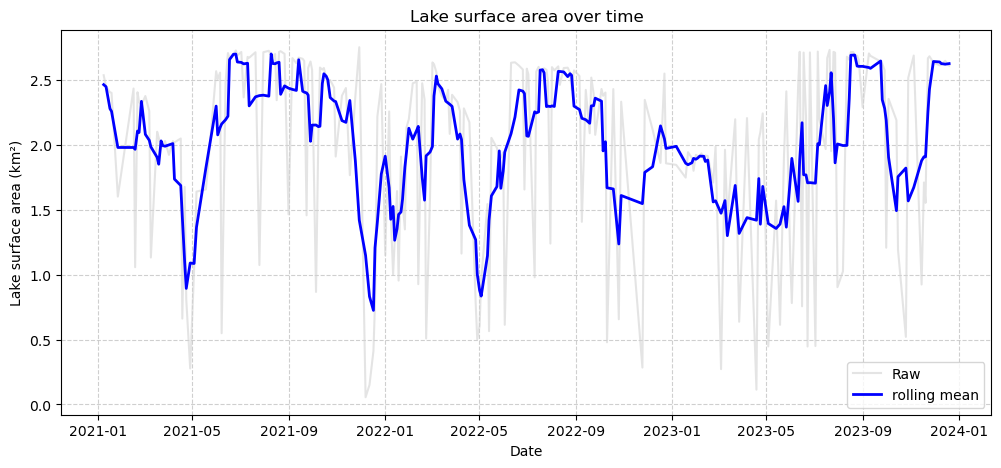

In [45]:
smoothed = water_area_ts.rolling(window=5, center=True, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(
    water_area_ts.index,
    water_area_ts.values / 1e6,
    color="lightgray",
    alpha=0.6,
    label="Raw",
)
plt.plot(
    smoothed.index,
    smoothed.values / 1e6,
    color="blue",
    linewidth=2,
    label="rolling mean",
)
plt.ylabel("Lake surface area (km²)")
plt.xlabel("Date")
plt.title("Lake surface area over time")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

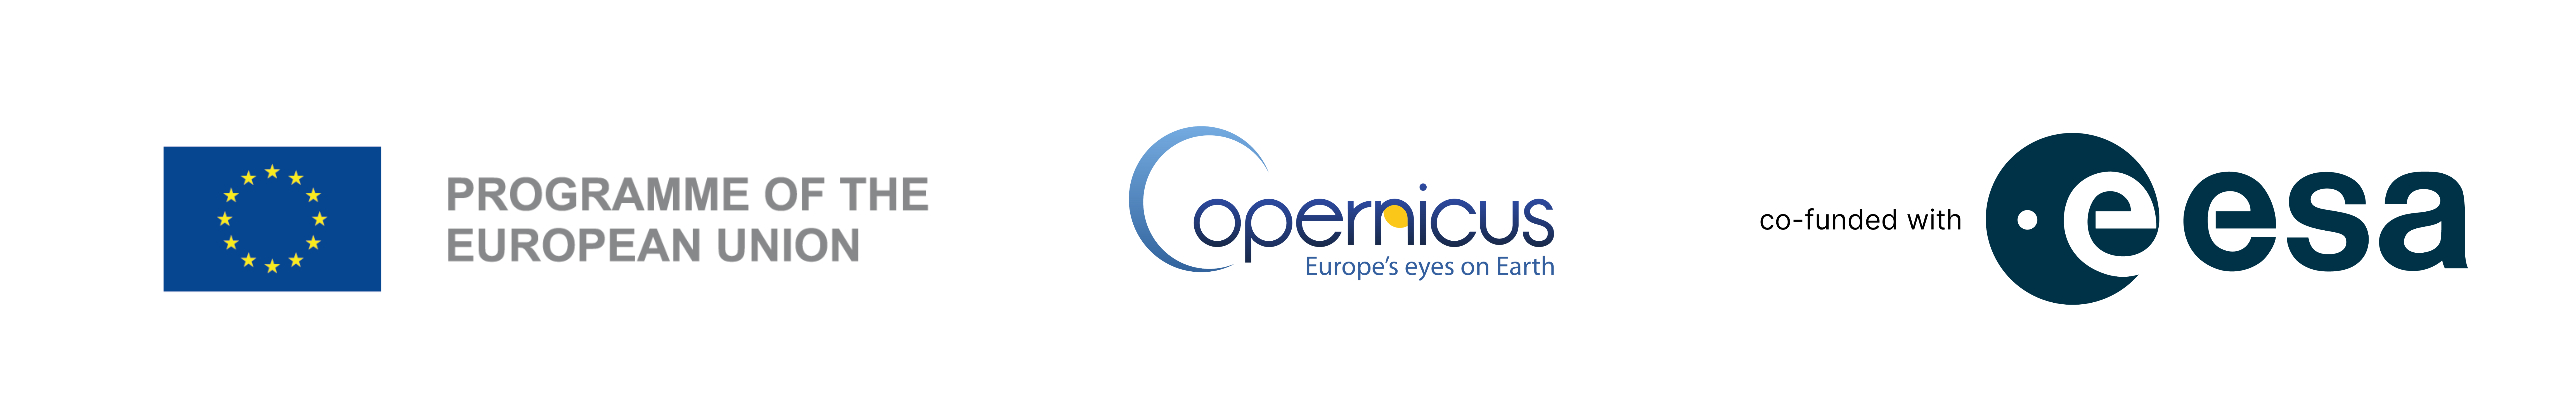